### Exporting rna for SCENIC+

RNA need to be log-normalized, and the previous object contains scaled values in adata.X

In [ ]:
import os

# Now import your libraries
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

import seaborn as sns

Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)

In [ ]:
rcParams["figure.figsize"] = (5, 5)

In [ ]:
directory = "mosaic_integration_scglue/"

In [ ]:
rna_anndata = ad.read(os.path.join(directory, "dmg_atlas_rna_full_GEX_v3.h5ad"))
rna_anndata

/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 397794 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sampl

In [ ]:
print(rna_anndata.layers['counts'])

  (1, 0)	5.0
  (5, 0)	1.0
  (18, 0)	2.0
  (47, 0)	1.0
  (78, 0)	1.0
  (108, 0)	1.0
  (109, 0)	1.0
  (156, 0)	1.0
  (159, 0)	1.0
  (165, 0)	1.0
  (173, 0)	1.0
  (247, 0)	1.0
  (265, 0)	1.0
  (299, 0)	1.0
  (311, 0)	1.0
  (329, 0)	1.0
  (346, 0)	1.0
  (369, 0)	1.0
  (383, 0)	1.0
  (385, 0)	1.0
  (415, 0)	1.0
  (441, 0)	1.0
  (445, 0)	1.0
  (462, 0)	1.0
  (546, 0)	1.0
  :	:
  (396920, 19247)	1.0
  (396923, 19247)	1.0
  (397006, 19247)	1.0
  (397023, 19247)	1.0
  (397036, 19247)	1.0
  (397050, 19247)	1.0
  (397052, 19247)	1.0
  (397058, 19247)	1.0
  (397060, 19247)	1.0
  (397061, 19247)	1.0
  (397066, 19247)	1.0
  (397070, 19247)	1.0
  (397075, 19247)	1.0
  (397114, 19247)	1.0
  (397119, 19247)	1.0
  (397130, 19247)	1.0
  (397141, 19247)	1.0
  (397181, 19247)	1.0
  (397188, 19247)	1.0
  (397217, 19247)	1.0
  (397220, 19247)	1.0
  (397228, 19247)	1.0
  (397231, 19247)	1.0
  (397389, 19247)	1.0
  (397487, 19247)	1.0


In [ ]:
rna_anndata.X, rna_anndata.X.data

(array([[-0.20920948, -0.04209522, -0.46742258, ...,  0.45855098,
         -0.26919565,  0.35292056],
        [ 6.93713097, -0.04209522, -0.46742258, ...,  0.60742597,
         -0.26919565,  1.21262434],
        [-0.20920948, -0.04209522,  0.23010227, ..., -0.45210292,
         -0.26919565,  0.63529951],
        ...,
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516]]),
 <memory at 0x7fe49c5af9f0>)

In [ ]:
rna_anndata.X = rna_anndata.layers["counts"].copy()

rna_anndata.obs['MP_rna'] = rna_anndata.obs['MP']

In [ ]:
rna_anndata.X, rna_anndata.X.data

(<397794x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 835603632 stored elements in Compressed Sparse Column format>,
 array([5., 1., 2., ..., 1., 1., 1.]))

In [ ]:
rna_anndata.raw = rna_anndata

In [ ]:
sc.pp.normalize_total(rna_anndata, target_sum=1e4)
sc.pp.log1p(rna_anndata)

In [ ]:
rna_anndata.X, rna_anndata.X.data

(<397794x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 835603632 stored elements in Compressed Sparse Column format>,
 array([1.87739963, 1.03950589, 1.89289625, ..., 2.47696901, 2.83321334,
        2.96785656]))

In [ ]:
rna_anndata.write('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/pyscenic_dmg_atlas/dmg_rna_atlas_v4.h5ad',
                 compression='gzip')

## Running SCENIC+

In [ ]:
!scenicplus


   ____   ____ _____ _   _ ___ ____      
  / ___| / ___| ____| \ | |_ _/ ___| _ 
  \___ \| |   |  _| |  \| || | |   _|.|_
   ___) | |___| |___| |\  || | |__|_..._|
  |____/ \____|_____|_| \_|___\____||_| 


scenicplus verions: 1.0a1
usage: scenicplus [-h] {init_snakemake,prepare_data,grn_inference} ...

Single-Cell Enhancer-driven gene regulatory Network Inference and Clustering

positional arguments:
  {init_snakemake,prepare_data,grn_inference}

options:
  -h, --help            show this help message and exit


In [ ]:
!tree scplus_pipeline_atlas/

scplus_pipeline_atlas/
└── Snakemake
    ├── config
    │   └── config.yaml
    └── workflow
        └── Snakefile

3 directories, 2 files


In [ ]:
!mkdir -p outs
!mkdir -p tmp

In [ ]:
!tree /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/pyscenic_dmg_atlas/region_sets

/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/pyscenic_dmg_atlas/region_sets
├── DARs_cell_type
│   ├── ACLike.bed
│   ├── Astrocyte.bed
│   ├── C1Q.bed
│   ├── CiliaLike.bed
│   ├── COPLike.bed
│   ├── Endothelial.bed
│   ├── GBlike.bed
│   ├── GWLike.bed
│   ├── Homeostatic.bed
│   ├── IL1B.bed
│   ├── IPCLike.bed
│   ├── LipidLaden.bed
│   ├── Lymphoid.bed
│   ├── MonoNeutrophil.bed
│   ├── Mural.bed
│   ├── Neuron.bed
│   ├── Oligodendrocyte.bed
│   ├── OPC.bed
│   ├── OPCLike.bed
│   ├── RGLike.bed
│   ├── Scavenger.bed
│   ├── TDLike.bed
│   └── TriIPCLike.bed
├── Topics_otsu
│   ├── Topic100.bed
│   ├── Topic10.bed
│   ├── Topic11.bed
│   ├── Topic12.bed
│   ├── Topic13.bed
│   ├── Topic14.bed
│   ├── Topic15.bed
│   ├── Topic16.bed
│   ├── Topic17.bed
│   ├── Topic18.bed
│   ├── Topic19.bed
│   ├── Topic1.bed
│   ├── Topic20.bed
│   ├── Topic21.bed
│   ├── Topic22.bed
│   ├── Topic23.bed
│   ├── Topic24.bed
│   ├── Topic25.bed
│   ├── Topic26.bed
│   ├── Topic27.bed
│   

In [ ]:
!bat scplus_pipeline_atlas/Snakemake/config/config.yaml

───────┬────────────────────────────────────────────────────────────────────────
       │ File: scplus_pipeline_atlas/Snakemake/config/config.yaml
───────┼────────────────────────────────────────────────────────────────────────
   1   │ input_data:
   2   │   cisTopic_obj_fname: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/
       │ data/pyscenic_dmg_atlas/cistopic_obj.pkl"
   3   │   GEX_anndata_fname: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/d
       │ ata/pyscenic_dmg_atlas/dmg_rna_atlas_v4.h5ad"
   4   │   region_set_folder: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/d
       │ ata/pyscenic_dmg_atlas/region_sets"
   5   │   ctx_db_fname: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/c
       │ istargetdb/hg38_screen_v10_clust.regions_vs_motifs.rankings.feather"
   6   │   dem_db_fname: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/c
       │ istargetdb/hg38_screen_v10_clust.regions_vs_motifs.scores.feather"
   7   │   path_to_motif_annotations: "/p

In [ ]:
cd scplus_pipeline_atlas/Snakemake/

/gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/scplus_pipeline_atlas/Snakemake


/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
ls

config/  workflow/


In [ ]:
!snakemake --cores 64
# error solved  after updating dask
# pip install dask==2024.4.1
# https://github.com/aertslab/scenicplus/issues/408
# https://github.com/aertslab/scenicplus/issues/381

Assuming unrestricted shared filesystem usage for local execution.
Building DAG of jobs...
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Using shell: /usr/bin/bash
Provided cores: 64
Rules claiming more threads will be scaled down.
Job stats:
job                             count
----------------------------  -------
AUCell_direct                       1
AUCell_extended                     1
all                                 1
download_genome_annotations         1
eGRN_direct                         1
eGRN_extended                       1
get_search_space                    1
motif_enrichment_cistarget          1
motif_enrichment_dem                1
prepare_GEX_ACC_non_multiome        1
prepare_menr                        1
region_to_gene                      1
scplus_mudata                       1
tf_to_gene                          1
total                              14

Select jobs to execute...
Execute 1 jobs...

[Mon Aug 12 16:21:32 2024

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Running using 64 cores: 100%|███████████| 19248/19248 [2:02:43<00:00,  2.61it/s]
2024-08-13 09:07:26,885 TF2G         INFO     Adding correlation coefficients to adjacencies.
2024-08-13 09:08:00,984 TF2G         INFO     Warning: adding TFs as their own target to adjecencies matrix. Importance values will be max + 1e-05
2024-08-13 09:08:06,925 SCENIC+      INFO     Saving TF to gene adjacencies to: /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/outs/tf_to_gene_adj.tsv
[Tue Aug 13 09:08:16 2024]
Finished job 5.
8 of 14 steps (57%) done
Select jobs to execute...
Execute 1 jobs...

[Tue Aug 13 09:08:16 2024]
localrule eGRN_direct:
    input: /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/outs/tf_to_gene_adj.tsv, /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/outs/region_to_gene_adj.tsv, /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/outs/cistromes_direct.h5ad, /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/cistargetdb/hg38_screen_v10_clust.regions_vs_motifs.rankings.feather
    

## Assesing outputs

In [ ]:
import os
os.chdir("/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/")

In [ ]:
import mudata
scplus_mdata = mudata.read("outs_dmg_atlas_v4//scplusmdata.h5mu")

/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/crui

In [ ]:
scplus_mdata

MuData object with n_obs × n_vars = 24924 × 395736
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	24924 x 19248
      obs:	'MP'
      var:	'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_id', 'gene_version', 'gene_type', 'hgnc_id', 'tag', 'havana_gene'
    scATAC_counts:	24924 x 374422
      obs:	'MP'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	24924 x 688
    direct_region_based_AUC:	24924 x 688
    extended_gene_based_AUC:	24924 x 345
    extended_region_based_AUC:	24924 x 345

In [ ]:
scplus_mdata.uns["direct_e_regulon_metadata"]

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr3:77328874-77329915,ROBO2,0.016158,0.261483,0.004225,0.004225,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),1.784048,1,0.489617,170081
1,chr9:119157285-119158518,BRINP1,0.025454,0.304732,0.007757,0.007757,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.324853,1,0.173979,224335
2,chr7:14339634-14340524,DGKB,0.027651,0.621275,0.017179,0.017179,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),1.170801,1,0.384082,194709
3,chr12:110531574-110532599,TCTN1,0.052186,0.345784,0.018045,0.018045,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.743310,1,0.298236,227916
4,chr11:32087938-32089029,RCN1,0.040007,0.426300,0.017055,0.017055,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.250146,1,0.237303,315361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414108,chr9:69759440-69760453,APBA1,0.007455,-0.161351,-0.001203,0.001203,ZNF846,False,ZNF846_direct_-/-,ZNF846_direct_-/-_(27g),ZNF846_direct_-/-_(56r),0.085289,-1,-0.054241,301055
414109,chr15:83010775-83012149,HDGFL3,0.075351,-0.283573,-0.021367,0.021367,ZNF846,False,ZNF846_direct_-/-,ZNF846_direct_-/-_(27g),ZNF846_direct_-/-_(56r),0.045916,-1,-0.065083,205931
414110,chr6:28922636-28923278,ZNF311,0.067250,-0.070306,-0.004728,0.004728,ZNF846,False,ZNF846_direct_-/-,ZNF846_direct_-/-_(27g),ZNF846_direct_-/-_(56r),0.047548,-1,-0.050334,147611
414111,chr11:414427-415482,PTDSS2,0.072011,-0.153459,-0.011051,0.011051,ZNF846,False,ZNF846_direct_-/-,ZNF846_direct_-/-_(27g),ZNF846_direct_-/-_(56r),0.020306,-1,-0.079849,294121


In [ ]:
scplus_mdata.uns["extended_e_regulon_metadata"]

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr2:231049944-231051047,ARMC9,0.070256,0.398626,0.028006,0.028006,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),0.566140,1,0.326379,107173
1,chr4:31235777-31236895,PCDH7,0.032196,0.444975,0.014326,0.014326,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),3.620270,1,0.453750,52629
2,chr11:73257170-73259591,ARHGEF17,0.048626,0.401674,0.019532,0.019532,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),0.557222,1,0.281205,153323
3,chr1:208047106-208048589,PLXNA2,0.007376,0.367108,0.002708,0.002708,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),0.341280,1,0.303208,154005
4,chr3:77328874-77329915,ROBO2,0.016158,0.261483,0.004225,0.004225,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),1.784048,1,0.489617,86757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219998,chr2:152717071-152718003,FMNL2,0.007245,-0.051398,-0.000372,0.000372,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.064707,-1,-0.176868,208255
219999,chr5:133051416-133052427,FSTL4,0.008822,-0.283593,-0.002502,0.002502,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.053228,-1,-0.184341,161893
220000,chr3:9933272-9934186,OGG1,0.021472,-0.065544,-0.001407,0.001407,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.044213,-1,-0.056784,56666
220001,chr19:48398274-48399195,TMEM143,0.034749,-0.116967,-0.004065,0.004065,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.085539,-1,-0.079934,162851


## Downstream analysis

### eRegulon specificity score

In [ ]:
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)

In [ ]:
rss = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:MP",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)

In [ ]:
rss

,AFF4_direct_-/-_(11g),AHR_direct_+/-_(55g),AHR_direct_-/+_(15g),AHR_direct_-/-_(37g),APEX1_direct_-/+_(24g),APEX1_direct_-/-_(14g),ARID3A_direct_+/+_(55g),ARID3A_direct_+/-_(143g),ARID3A_direct_-/+_(84g),ARNT_direct_+/-_(14g),...,UNCX_extended_+/+_(25g),VENTX_extended_+/-_(14g),XBP1_extended_+/+_(165g),XBP1_extended_-/-_(11g),YY1_extended_+/+_(26g),YY1_extended_+/-_(13g),ZBTB7A_extended_+/+_(21g),ZNF367_extended_+/-_(51g),ZNF641_extended_+/+_(50g),ZNF672_extended_+/+_(10g)
ACLike,0.190549,0.232282,0.271054,0.245104,0.235775,0.241541,0.209063,0.208568,0.266865,0.241976,...,0.221159,0.167445,0.187129,0.252381,0.192153,0.175121,0.175444,0.180622,0.202431,0.167781
Astrocyte,0.167445,0.225538,0.175734,0.179048,0.201577,0.202434,0.196271,0.193727,0.197714,0.206327,...,0.204816,0.167445,0.186920,0.206847,0.206340,0.196660,0.169128,0.167724,0.172730,0.167445
C1Q,0.169802,0.181595,0.212686,0.306323,0.177614,0.181541,0.205840,0.199730,0.168359,0.174999,...,0.167445,0.168399,0.293704,0.194272,0.216693,0.197838,0.171728,0.176074,0.240856,0.178460
COPLike,0.168943,0.239034,0.268996,0.263037,0.241154,0.229812,0.256187,0.254550,0.210160,0.217439,...,0.167593,0.167445,0.181402,0.247589,0.208510,0.195869,0.172431,0.168142,0.258370,0.167813
CiliaLike,0.168094,0.198186,0.173331,0.175168,0.193005,0.194699,0.185479,0.185438,0.184453,0.194468,...,0.199861,0.167445,0.194007,0.186092,0.194073,0.188808,0.169146,0.168519,0.171483,0.167445
Endothelial,0.199900,0.176400,0.169016,0.176623,0.179269,0.180735,0.180570,0.182267,0.171441,0.175770,...,0.167445,0.167445,0.175312,0.171511,0.179096,0.178113,0.178456,0.168052,0.171782,0.177325
GBlike,0.168006,0.227142,0.181297,0.173995,0.207968,0.209153,0.199598,0.200125,0.196871,0.210598,...,0.274744,0.167445,0.193407,0.202996,0.210188,0.206972,0.171081,0.169997,0.174284,0.167445
GWLike,0.168139,0.242555,0.191576,0.180403,0.217790,0.217711,0.215462,0.216357,0.196156,0.223673,...,0.204213,0.167445,0.205476,0.203914,0.224841,0.228166,0.175368,0.169753,0.184604,0.167445
Homeostatic,0.168556,0.178626,0.197150,0.229940,0.184913,0.187282,0.198658,0.195457,0.169937,0.183436,...,0.167445,0.167445,0.172890,0.178670,0.173288,0.172051,0.171861,0.168888,0.280456,0.169558
IL1B,0.167445,0.177192,0.195197,0.229199,0.180750,0.183046,0.196401,0.192619,0.168411,0.178041,...,0.167445,0.167445,0.190254,0.178166,0.177812,0.179284,0.170883,0.167840,0.265058,0.167445


In [ ]:
import matplotlib.pyplot as pl

pl.rcParams['pdf.fonttype'] = 42

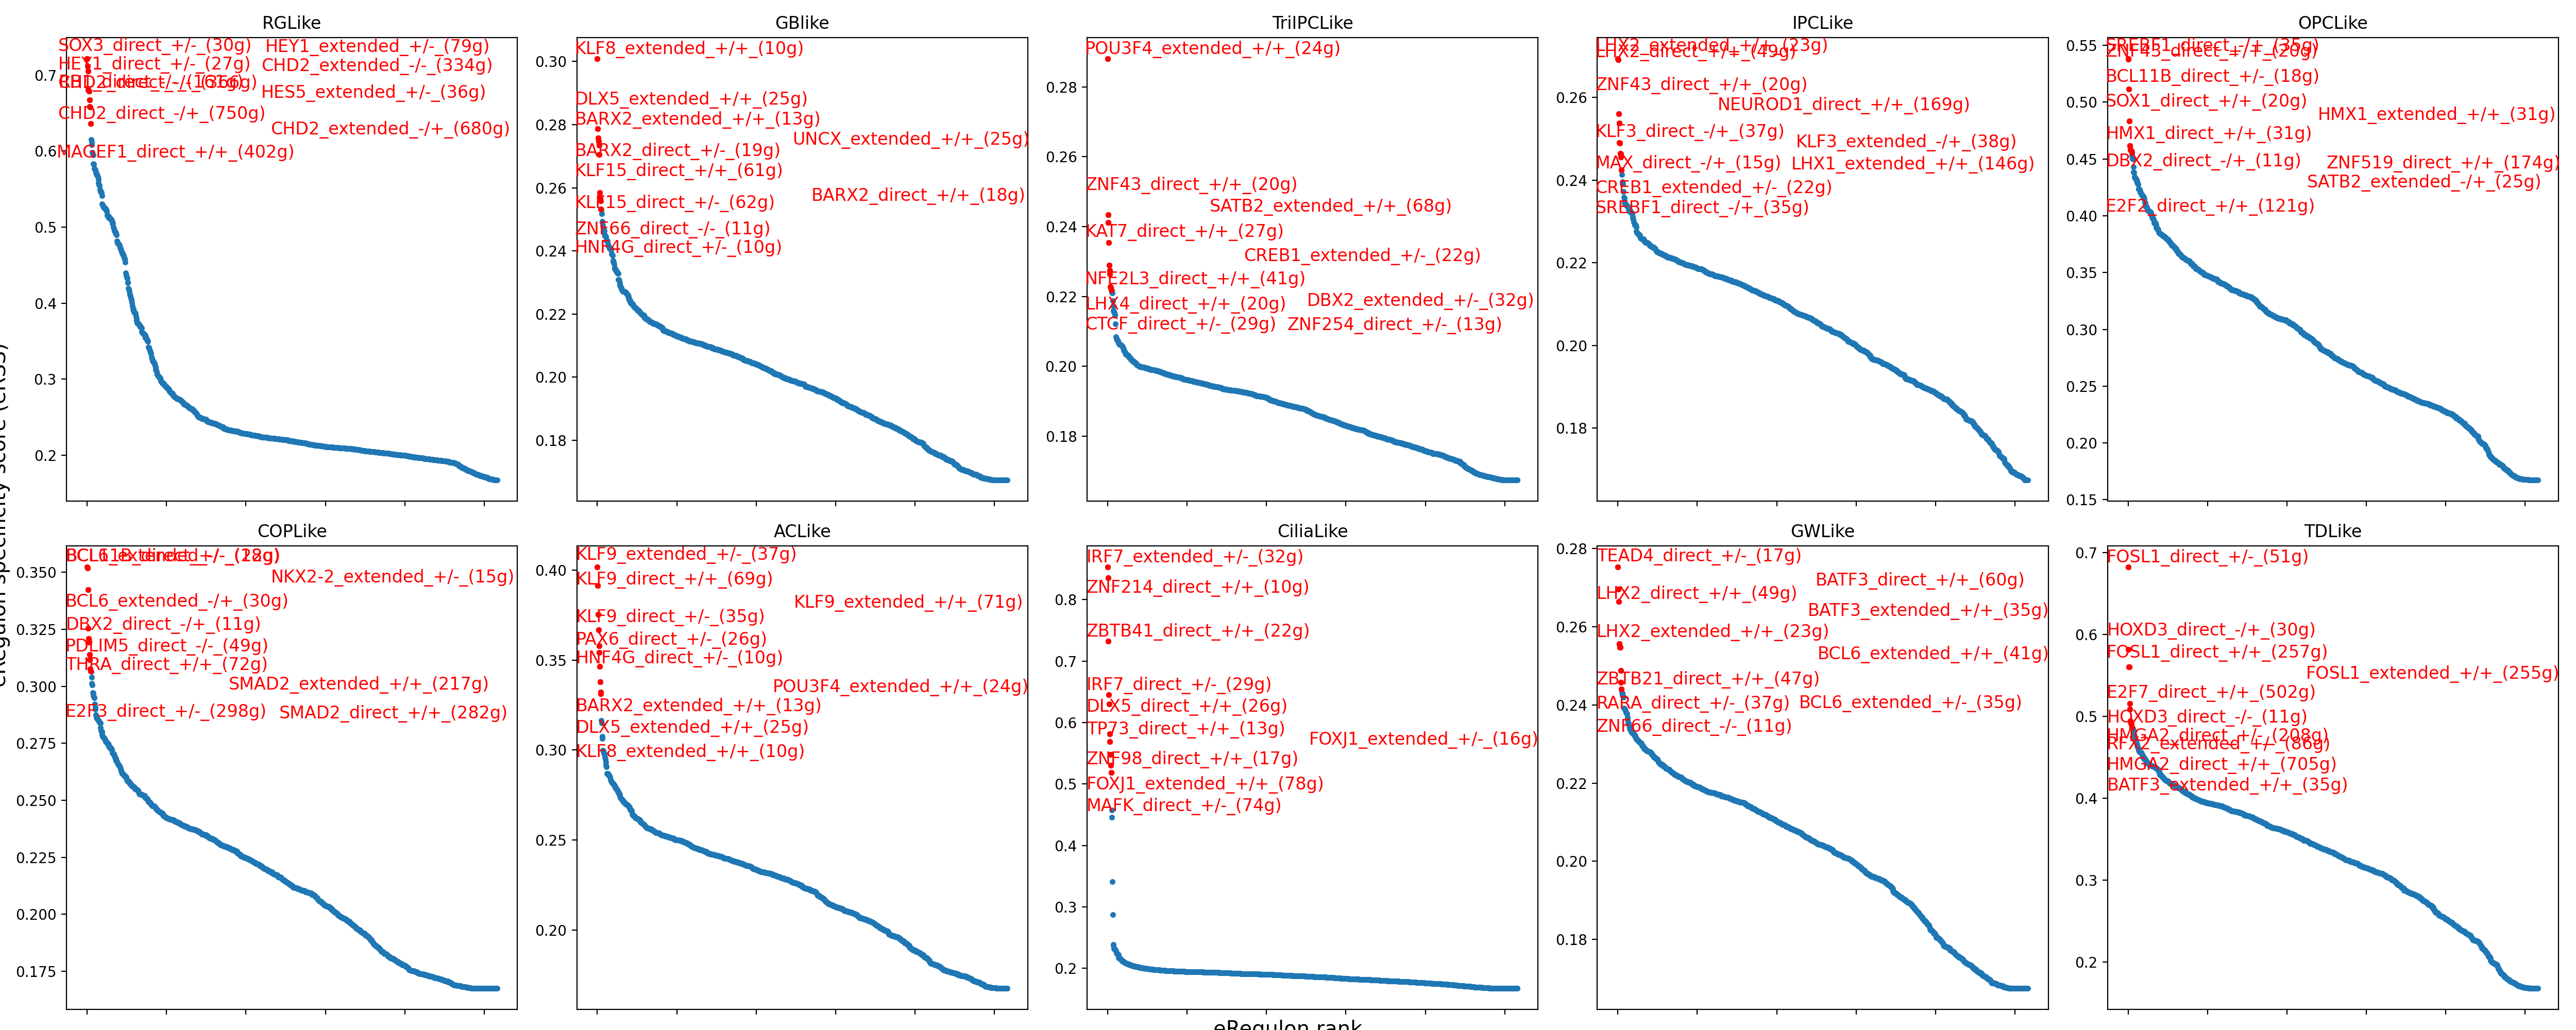

In [ ]:
plot_rss(
    data_matrix = rss,
    selected_groups = ['RGLike','GBlike', 'TriIPCLike', 'IPCLike','OPCLike','COPLike','ACLike','CiliaLike', 'GWLike','TDLike'],
    top_n = 10,
    fontsize=12,
    num_columns = 5,
    figsize=(5,5),
    save='figures/eRSS_per_malignant_MP.pdf'
)

### Plot GRN

In [20]:
direct_md = scplus_obj.uns['eRegulon_metadata']
direct_md

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr3:77328874-77329915,ROBO2,0.016158,0.261483,0.004225,0.004225,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),1.784048,1,0.489617,170081
1,chr9:119157285-119158518,BRINP1,0.025454,0.304732,0.007757,0.007757,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.324853,1,0.173979,224335
2,chr7:14339634-14340524,DGKB,0.027651,0.621275,0.017179,0.017179,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),1.170801,1,0.384082,194709
3,chr12:110531574-110532599,TCTN1,0.052186,0.345784,0.018045,0.018045,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.743310,1,0.298236,227916
4,chr11:32087938-32089029,RCN1,0.040007,0.426300,0.017055,0.017055,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.250146,1,0.237303,315361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634111,chr2:152717071-152718003,FMNL2,0.007245,-0.051398,-0.000372,0.000372,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.064707,-1,-0.176868,208255
634112,chr5:133051416-133052427,FSTL4,0.008822,-0.283593,-0.002502,0.002502,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.053228,-1,-0.184341,161893
634113,chr3:9933272-9934186,OGG1,0.021472,-0.065544,-0.001407,0.001407,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.044213,-1,-0.056784,56666
634114,chr19:48398274-48399195,TMEM143,0.034749,-0.116967,-0.004065,0.004065,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.085539,-1,-0.079934,162851


In [21]:
direct_filt = direct_md[direct_md['TF'].isin(['FOSL1', 'HMGA2', 'HOXD3', 'PLAG1', 'YY1'])]
direct_filt

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
63929,chr2:232979659-232980722,NGEF,0.089138,0.525014,0.046799,0.046799,FOSL1,False,FOSL1_direct_+/+,FOSL1_direct_+/+_(257g),FOSL1_direct_+/+_(1241r),0.195841,1,0.151107,142663
63930,chr14:55107576-55108762,LGALS3,0.071257,0.615066,0.043828,0.043828,FOSL1,False,FOSL1_direct_+/+,FOSL1_direct_+/+_(257g),FOSL1_direct_+/+_(1241r),0.349491,1,0.294525,139310
63931,chr1:44029665-44031011,ATP6V0B,0.006729,0.179739,0.001209,0.001209,FOSL1,False,FOSL1_direct_+/+,FOSL1_direct_+/+_(257g),FOSL1_direct_+/+_(1241r),0.106905,1,0.140768,388208
63932,chr3:184261096-184262175,EIF4G1,0.033731,0.296515,0.010002,0.010002,FOSL1,False,FOSL1_direct_+/+,FOSL1_direct_+/+_(257g),FOSL1_direct_+/+_(1241r),0.057484,1,0.165220,233839
63933,chr1:31760490-31761537,SPOCD1,0.064587,0.576943,0.037263,0.037263,FOSL1,False,FOSL1_direct_+/+,FOSL1_direct_+/+_(257g),FOSL1_direct_+/+_(1241r),0.325529,1,0.224641,247510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625258,chr14:24070942-24073717,IRF9,0.062845,-0.137326,-0.008630,0.008630,PLAG1,True,PLAG1_extended_-/-,PLAG1_extended_-/-_(85g),PLAG1_extended_-/-_(136r),0.117993,-1,-0.066740,111426
625259,chr20:45934291-45935666,MMP9,0.047202,-0.050231,-0.002371,0.002371,PLAG1,True,PLAG1_extended_-/-,PLAG1_extended_-/-_(85g),PLAG1_extended_-/-_(136r),0.107163,-1,-0.080045,202972
625260,chr10:102555630-102556678,ACTR1A,0.033448,-0.133822,-0.004476,0.004476,PLAG1,True,PLAG1_extended_-/-,PLAG1_extended_-/-_(85g),PLAG1_extended_-/-_(136r),0.080875,-1,-0.120787,173590
625261,chr1:17439198-17440324,PADI4,0.065276,-0.119489,-0.007800,0.007800,PLAG1,True,PLAG1_extended_-/-,PLAG1_extended_-/-_(85g),PLAG1_extended_-/-_(136r),0.150376,-1,-0.109785,162900


In [22]:
scplus_obj.uns['direct_e_regulon_metadata_filtered'] = direct_filt

In [23]:
from pycisTopic.diff_features import find_highly_variable_features

#scplus_obj.uns['direct_e_regulon_metadata_filtered'] = scplus_mdata.uns['direct_e_regulon_metadata_filtered']

hvr = find_highly_variable_features(scplus_obj.to_df('ACC').loc[list(set(scplus_obj.uns['direct_e_regulon_metadata_filtered']['Region']))], n_top_features=1000, plot = False)
hvg = find_highly_variable_features(scplus_obj.to_df('EXP')[list(set(scplus_obj.uns['direct_e_regulon_metadata_filtered']['Gene']))].T, n_top_features=1000, plot = False)

In [15]:
direct_md = scplus_obj.uns['eRegulon_metadata']
direct_md

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr3:77328874-77329915,ROBO2,0.016158,0.261483,0.004225,0.004225,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),1.784048,1,0.489617,170081
1,chr9:119157285-119158518,BRINP1,0.025454,0.304732,0.007757,0.007757,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.324853,1,0.173979,224335
2,chr7:14339634-14340524,DGKB,0.027651,0.621275,0.017179,0.017179,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),1.170801,1,0.384082,194709
3,chr12:110531574-110532599,TCTN1,0.052186,0.345784,0.018045,0.018045,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.743310,1,0.298236,227916
4,chr11:32087938-32089029,RCN1,0.040007,0.426300,0.017055,0.017055,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.250146,1,0.237303,315361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634111,chr2:152717071-152718003,FMNL2,0.007245,-0.051398,-0.000372,0.000372,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.064707,-1,-0.176868,208255
634112,chr5:133051416-133052427,FSTL4,0.008822,-0.283593,-0.002502,0.002502,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.053228,-1,-0.184341,161893
634113,chr3:9933272-9934186,OGG1,0.021472,-0.065544,-0.001407,0.001407,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.044213,-1,-0.056784,56666
634114,chr19:48398274-48399195,TMEM143,0.034749,-0.116967,-0.004065,0.004065,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.085539,-1,-0.079934,162851


In [16]:
direct_filt = direct_md[direct_md['TF'].isin(['FOSL1', 'HMGA2', 'HOXD3', 'E2F7'])]
direct_filt

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
19915,chr11:2891846-2893022,PHLDA2,0.024536,0.072446,0.001778,0.001778,E2F7,False,E2F7_direct_+/+,E2F7_direct_+/+_(502g),E2F7_direct_+/+_(1245r),1.089928,1,0.238402,215070
19916,chr1:31763866-31765890,SPOCD1,0.043217,0.540515,0.023359,0.023359,E2F7,False,E2F7_direct_+/+,E2F7_direct_+/+_(502g),E2F7_direct_+/+_(1245r),4.185909,1,0.486978,33950
19917,chr7:48090137-48091065,UPP1,0.038755,0.424056,0.016434,0.016434,E2F7,False,E2F7_direct_+/+,E2F7_direct_+/+_(502g),E2F7_direct_+/+_(1245r),0.985955,1,0.255410,281883
19918,chr4:76950266-76951503,SEPTIN11,0.056238,0.524877,0.029518,0.029518,E2F7,False,E2F7_direct_+/+,E2F7_direct_+/+_(502g),E2F7_direct_+/+_(1245r),0.773400,1,0.351622,240944
19919,chr17:81977126-81978165,P4HB,0.033234,0.302672,0.010059,0.010059,E2F7,False,E2F7_direct_+/+,E2F7_direct_+/+_(502g),E2F7_direct_+/+_(1245r),1.137824,1,0.255276,53785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578297,chr1:197783241-197784288,DENND1B,0.029886,0.465566,0.013914,0.013914,FOSL1,True,FOSL1_extended_-/+,FOSL1_extended_-/+_(10g),FOSL1_extended_-/+_(17r),0.068295,-1,-0.094893,214881
578298,chr1:164706627-164708616,PBX1,0.033086,0.457348,0.015132,0.015132,FOSL1,True,FOSL1_extended_-/+,FOSL1_extended_-/+_(10g),FOSL1_extended_-/+_(17r),0.039241,-1,-0.189127,215805
578299,chr2:190451389-190452296,HIBCH,0.033008,0.378057,0.012479,0.012479,FOSL1,True,FOSL1_extended_-/+,FOSL1_extended_-/+_(10g),FOSL1_extended_-/+_(17r),0.026689,-1,-0.122884,155297
578300,chr6:106574526-106575550,RTN4IP1,0.045379,0.090701,0.004116,0.004116,FOSL1,True,FOSL1_extended_-/+,FOSL1_extended_-/+_(10g),FOSL1_extended_-/+_(17r),0.026292,-1,-0.053406,161549


In [17]:
scplus_obj.uns['direct_e_regulon_metadata_filtered'] = direct_filt

In [18]:
from pycisTopic.diff_features import find_highly_variable_features

#scplus_obj.uns['direct_e_regulon_metadata_filtered'] = scplus_mdata.uns['direct_e_regulon_metadata_filtered']

hvr = find_highly_variable_features(scplus_obj.to_df('ACC').loc[list(set(scplus_obj.uns['direct_e_regulon_metadata_filtered']['Region']))], n_top_features=1000, plot = False)
hvg = find_highly_variable_features(scplus_obj.to_df('EXP')[list(set(scplus_obj.uns['direct_e_regulon_metadata_filtered']['Gene']))].T, n_top_features=1000, plot = False)

2024-09-14 11:20:23,484 cisTopic     INFO     Calculating mean
2024-09-14 11:20:23,554 cisTopic     INFO     Calculating variance
2024-09-14 11:20:24,019 cisTopic     INFO     Done!
2024-09-14 11:20:24,310 cisTopic     INFO     Calculating mean
2024-09-14 11:20:24,332 cisTopic     INFO     Calculating variance
2024-09-14 11:20:24,478 cisTopic     INFO     Done!


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [19]:
from scenicplus.networks import create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape

nx_tables = list()

In [43]:
import pandas as pd
import anndata
import scanpy as sc
from typing import List, Optional

def _format_df_nx(df, key, var):
    """
    A helper function to format differential test results
    """
    df.index = df['names']
    df = pd.DataFrame(df['logfoldchanges'])
    df.columns = [var+'_Log2FC_'+key]
    df.index.name = None
    return df


def _get_log2fc_nx(scplus_obj: 'SCENICPLUS',
                  variable,
                  features,
                  contrast: Optional[str] = 'gene'
                  ):
    """
    A helper function to derive log2fc changes
    """
    if contrast == 'gene':
        adata = anndata.AnnData(X=scplus_obj.X_EXP, obs=pd.DataFrame(
            index=scplus_obj.cell_names), var=pd.DataFrame(index=scplus_obj.gene_names))
    if contrast == 'region':
        adata = anndata.AnnData(X=scplus_obj.X_ACC.T, obs=pd.DataFrame(
            index=scplus_obj.cell_names), var=pd.DataFrame(index=scplus_obj.region_names))
    adata.obs = pd.DataFrame(scplus_obj.metadata_cell[variable])
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata = adata[:, features]
    sc.tl.rank_genes_groups(
        adata, variable, method='wilcoxon', corr_method='bonferroni')
    groups = adata.uns['rank_genes_groups']['names'].dtype.names
    diff_list = [_format_df_nx(sc.get.rank_genes_groups_df(
        adata, group=group), group, variable) for group in groups]
    return pd.concat(diff_list, axis=1)

def create_nx_tables(scplus_obj: 'SCENICPLUS',
                     eRegulon_metadata_key: str ='eRegulon_metadata',
                     subset_eRegulons: List = None,
                     subset_regions: List = None,
                     subset_genes: List = None,
                     add_differential_gene_expression: bool = False,
                     add_differential_region_accessibility: bool = False,
                     differential_variable: List =[]):
    """
    A function to format eRegulon data into tables for plotting eGRNs.
    
    Parameters
    ---------
    scplus_obj: SCENICPLUS
        A SCENICPLUS object with eRegulons
    eRegulon_metadata_key: str, optional
        Key where the eRegulon metadata dataframe is stored
    subset_eRegulons: list, optional
        List of eRegulons to subset
    subset_regions: list, optional
        List of regions to subset
    subset_genes: list, optional
        List of genes to subset
    add_differential_gene_expression: bool, optional
        Whether to calculate differential gene expression logFC for a given variable
    add_differential_region_accessibility: bool, optional
        Whether to calculate differential region accessibility logFC for a given variable
    differential_variable: list, optional
        Variable to calculate differential gene expression or region accessibility.
        
    Return
    ---------
    A dictionary with edge feature tables ('TF2G', 'TF2R', 'R2G') and node feature tables ('TF', 'Gene', 'Region')
    """
    er_metadata = scplus_obj.uns[eRegulon_metadata_key].copy()
    if subset_eRegulons is not None:
        # subset_eRegulons = [x + '_[^a-zA-Z0-9]' for x in subset_eRegulons]
        er_metadata = er_metadata[er_metadata['Region_signature_name'].str.contains(
            '|'.join(subset_eRegulons))]
    if subset_regions is not None:
        er_metadata = er_metadata[er_metadata['Region'].isin(subset_regions)]
    if subset_genes is not None:
        er_metadata = er_metadata[er_metadata['Gene'].isin(subset_genes)]
    nx_tables = {}
    nx_tables['Edge'] = {}
    nx_tables['Node'] = {}
    # Generate edge tables
    r2g_columns = [x for x in er_metadata.columns if 'R2G' in x]
    tf2g_columns = [x for x in er_metadata.columns if 'TF2G' in x]
    nx_tables['Edge']['TF2R'] = er_metadata[er_metadata.columns.difference(
        r2g_columns + tf2g_columns)].drop('Gene', axis=1).drop_duplicates()
    nx_tables['Edge']['TF2R'] = nx_tables['Edge']['TF2R'][['TF', 'Region'] +
                                                          nx_tables['Edge']['TF2R'].columns.difference(['TF', 'Region']).tolist()]
    nx_tables['Edge']['R2G'] = er_metadata[er_metadata.columns.difference(
        tf2g_columns)].drop('TF', axis=1).drop_duplicates()
    nx_tables['Edge']['R2G'] = nx_tables['Edge']['R2G'][['Region', 'Gene'] +
                                                        nx_tables['Edge']['R2G'].columns.difference(['Region', 'Gene']).tolist()]
    nx_tables['Edge']['TF2G'] = er_metadata[er_metadata.columns.difference(
        r2g_columns)].drop('Region', axis=1).drop_duplicates()
    nx_tables['Edge']['TF2G'] = nx_tables['Edge']['TF2G'][['TF', 'Gene'] +
                                                          nx_tables['Edge']['TF2G'].columns.difference(['TF', 'Gene']).tolist()]
    # Generate node tables
    tfs = list(set(er_metadata['TF']))
    nx_tables['Node']['TF'] = pd.DataFrame(
        'TF', index=tfs, columns=['Node_type'])
    nx_tables['Node']['TF']['TF'] = tfs
    genes = list(set(er_metadata['Gene']))
    genes = [x for x in genes if x not in tfs]
    nx_tables['Node']['Gene'] = pd.DataFrame(
        'Gene', index=genes, columns=['Node_type'])
    nx_tables['Node']['Gene']['Gene'] = genes
    regions = list(set(er_metadata['Region']))
    nx_tables['Node']['Region'] = pd.DataFrame(
        'Region', index=regions, columns=['Node_type'])
    nx_tables['Node']['Region']['Region'] = regions
    # Add gene logFC
    if add_differential_gene_expression is True:
        for var in differential_variable:
            nx_tables['Node']['TF'] = pd.concat([nx_tables['Node']['TF'], _get_log2fc_nx(
                scplus_obj, var, nx_tables['Node']['TF'].index.tolist(), contrast='gene')], axis=1)
            nx_tables['Node']['Gene'] = pd.concat([nx_tables['Node']['Gene'], _get_log2fc_nx(
                scplus_obj, var, nx_tables['Node']['Gene'].index.tolist(), contrast='gene')], axis=1)
    if add_differential_region_accessibility is True:
        for var in differential_variable:
            nx_tables['Node']['Region'] = pd.concat([nx_tables['Node']['Region'], _get_log2fc_nx(
                scplus_obj, var, nx_tables['Node']['Region'].index.tolist(), contrast='region')], axis=1)
    return nx_tables

In [57]:
from pycisTopic.diff_features import find_highly_variable_features

#scplus_obj.uns['direct_e_regulon_metadata_filtered'] = scplus_mdata.uns['direct_e_regulon_metadata_filtered']

hvr = find_highly_variable_features(scplus_obj.to_df('ACC').loc[list(set(scplus_obj.uns['direct_e_regulon_metadata_filtered']['Region']))], n_top_features=550, plot = False)
hvg = find_highly_variable_features(scplus_obj.to_df('EXP')[list(set(scplus_obj.uns['direct_e_regulon_metadata_filtered']['Gene']))].T, n_top_features=550, plot = False)

2024-09-14 11:59:05,572 cisTopic     INFO     Calculating mean
2024-09-14 11:59:05,639 cisTopic     INFO     Calculating variance
2024-09-14 11:59:06,093 cisTopic     INFO     Done!
2024-09-14 11:59:06,378 cisTopic     INFO     Calculating mean
2024-09-14 11:59:06,398 cisTopic     INFO     Calculating variance
2024-09-14 11:59:06,543 cisTopic     INFO     Done!


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [58]:
nx_table = create_nx_tables(
    scplus_obj = scplus_obj,
    eRegulon_metadata_key ='direct_e_regulon_metadata_filtered',
    subset_eRegulons = ['FOSL1', 'HMGA2', 'HOXD3', 'E2F7'],
    subset_regions = hvr,
    subset_genes = hvg,
    add_differential_gene_expression = True,
    add_differential_region_accessibility = True,
    differential_variable = ['MP']
)

/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:580: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat

In [59]:
G, pos, edge_tables, node_tables = create_nx_graph(nx_table, 
                   use_edge_tables = ['TF2R','R2G'],
                   color_edge_by = {'TF2R': {'variable' : 'TF', 'category_color' : {'FOSL1': 'Purple', 'HMGA2': 'Red', 'HOXD3' : 'Orange','E2F7' : 'Green'}},
                                    'R2G': {'variable' : 'importance_x_rho', 'continuous_color' : 'viridis', 'v_min': -1, 'v_max': 1}},
                   transparency_edge_by =  {'R2G': {'variable' : 'importance_R2G', 'min_alpha': 0.1, 'v_min': 0}},
                   width_edge_by = {'R2G': {'variable' : 'importance_R2G', 'max_size' :  1.5, 'min_size' : 1}},
                   color_node_by = {'TF': {'variable': 'TF', 'category_color' : {'FOSL1': 'Purple', 'HMGA2': 'Red', 'HOXD3' : 'Orange','E2F7' : 'Green'}},
                                    'Gene': {'variable': 'MP_Log2FC_TDLike', 'continuous_color' : 'bwr'},
                                    'Region': {'variable': 'MP_Log2FC_TDLike', 'continuous_color' : 'viridis'}},
                   transparency_node_by =  {'Region': {'variable' : 'MP_Log2FC_TDLike', 'min_alpha': 0.1},
                                    'Gene': {'variable' : 'MP_Log2FC_TDLike', 'min_alpha': 0.1}},
                   size_node_by = {'TF': {'variable': 'fixed_size', 'fixed_size': 30},
                                    'Gene': {'variable': 'fixed_size', 'fixed_size': 15},
                                    'Region': {'variable': 'fixed_size', 'fixed_size': 10}},
                   shape_node_by = {'TF': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Gene': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Region': {'variable': 'fixed_shape', 'fixed_shape': 'diamond'}},
                   label_size_by = {'TF': {'variable': 'fixed_label_size', 'fixed_label_size': 20.0},
                                    'Gene': {'variable': 'fixed_label_size', 'fixed_label_size': 10.0},
                                    'Region': {'variable': 'fixed_label_size', 'fixed_label_size': 0.0}},
                   layout='kamada_kawai_layout',
                   scale_position_by=250)

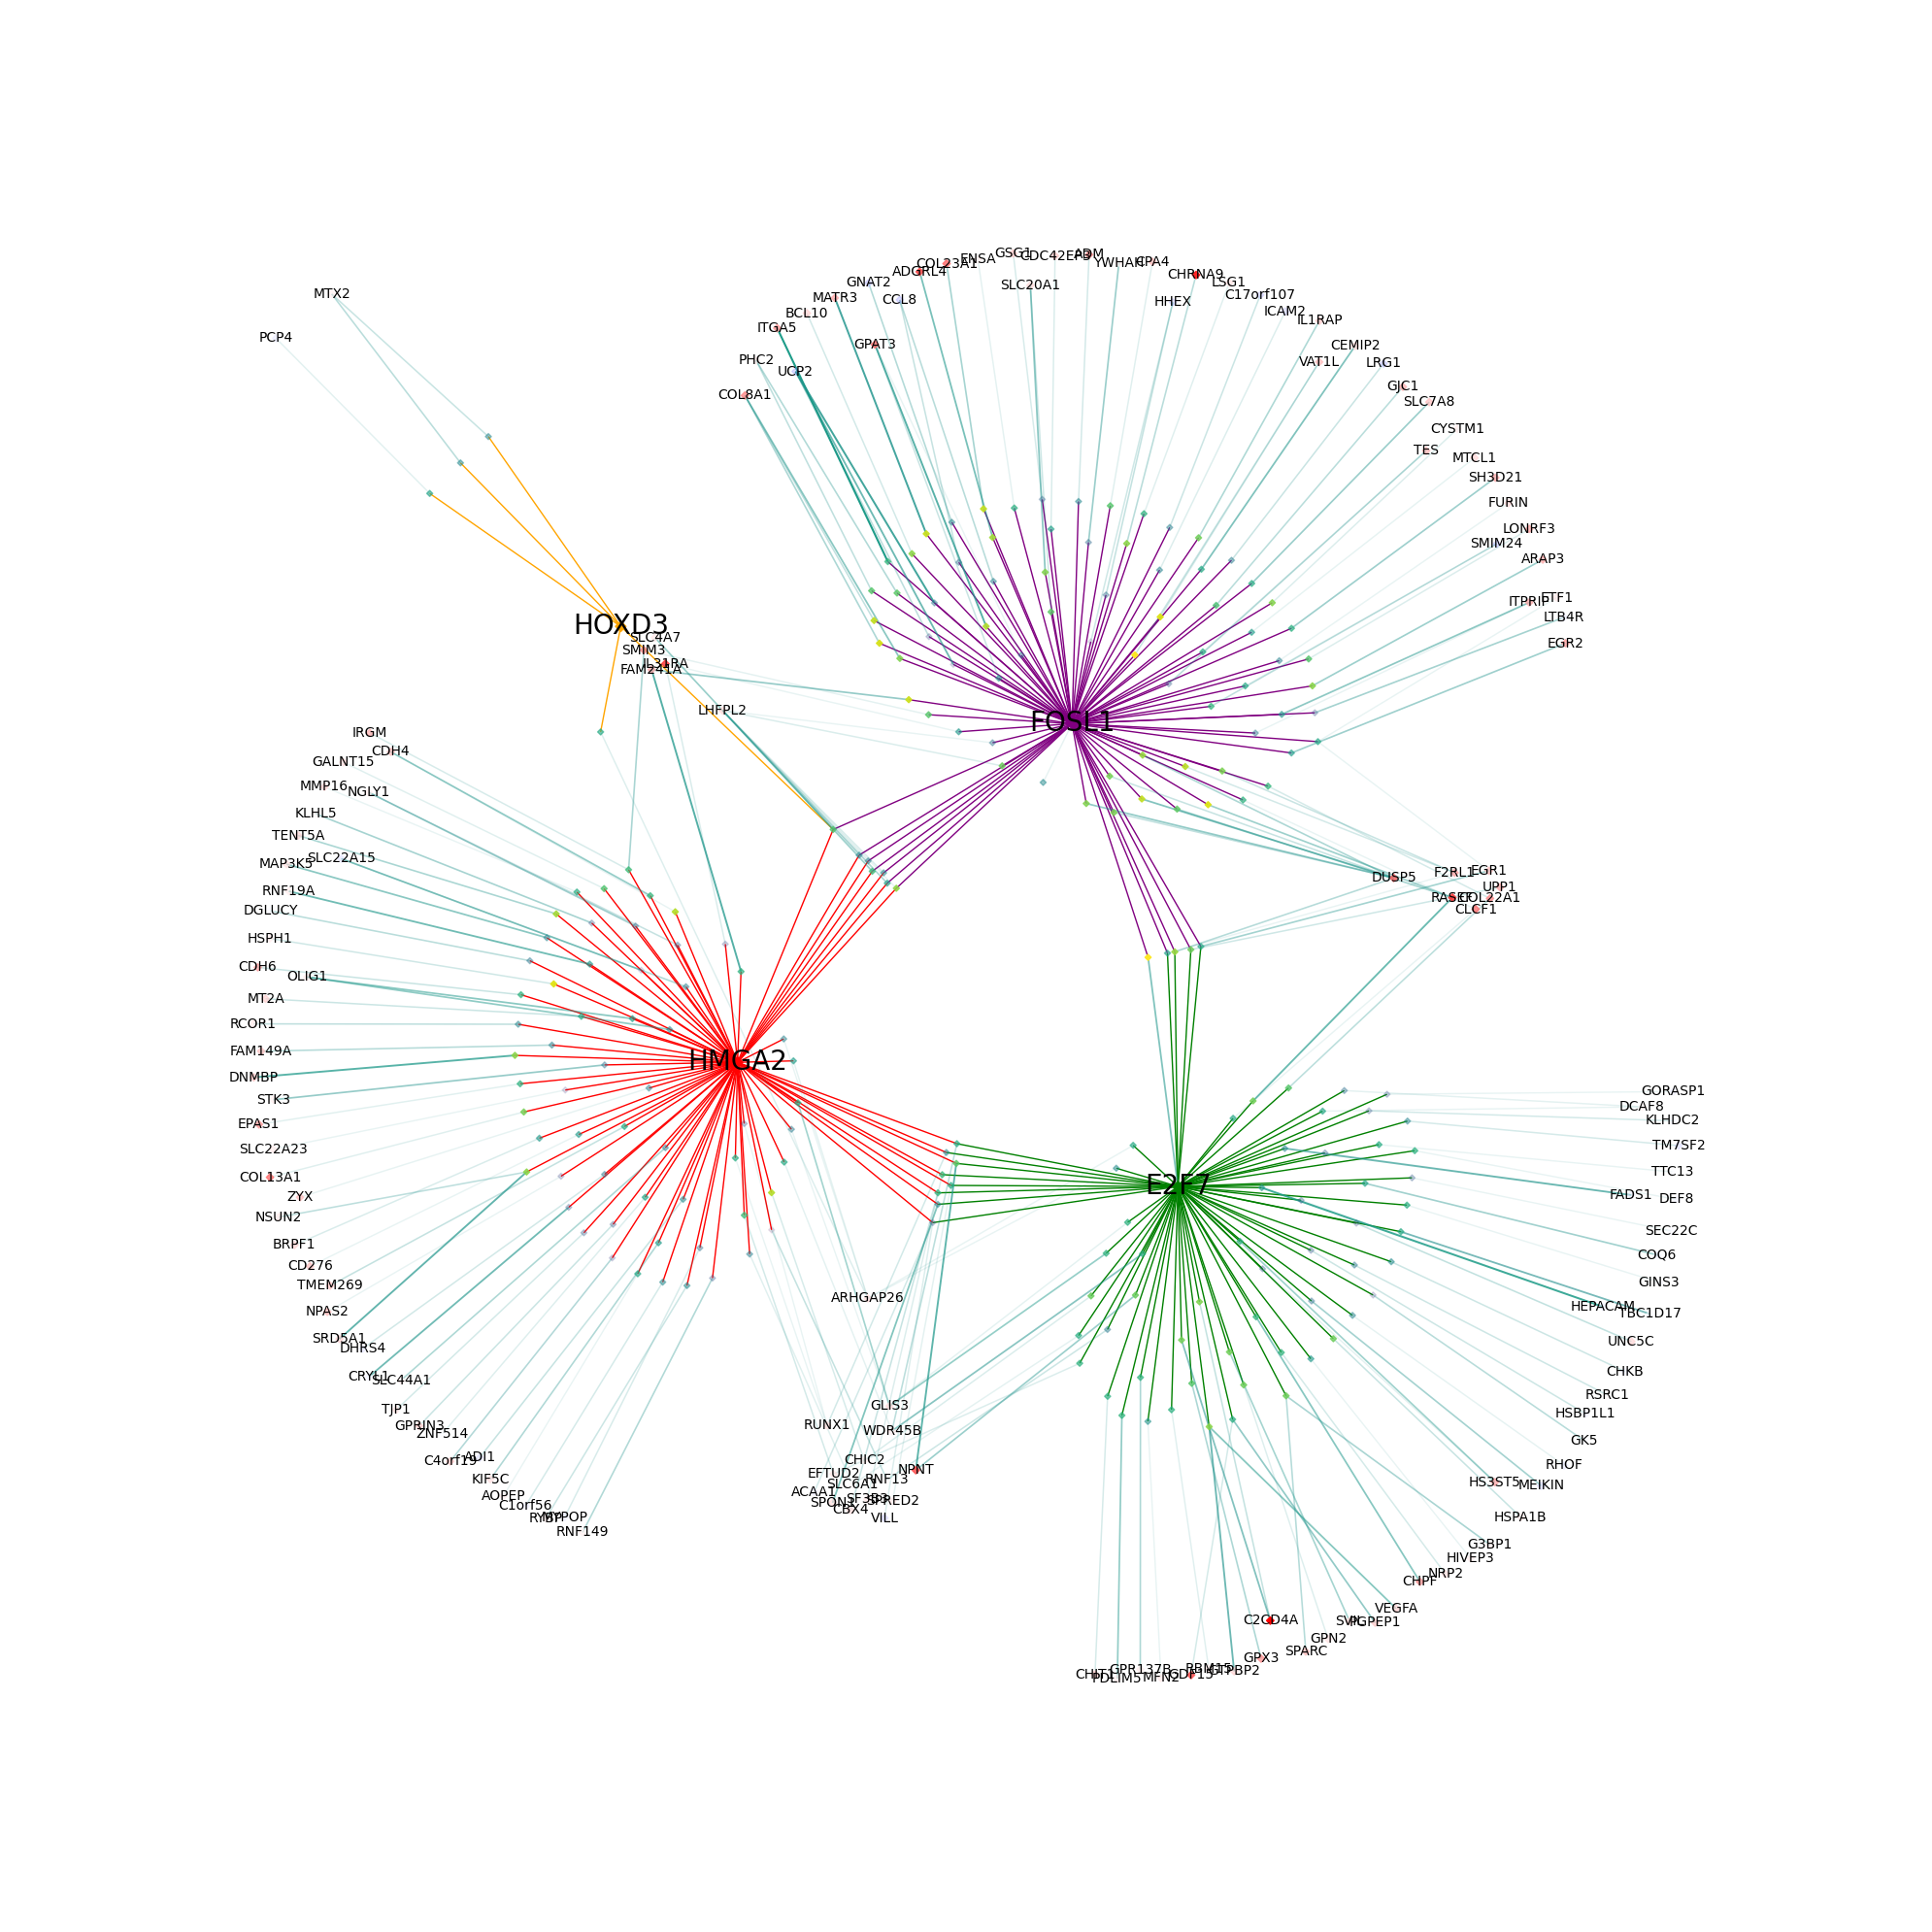

In [60]:
plt.figure(figsize=(20,20))
plot_networkx(G, pos)

In [56]:
export_to_cytoscape(G, pos, out_file = os.path.join('TDLike_network_downsampled.cyjs'))